# Application A — request latency

**Question:** How do we predict latency, check an optimizer, and handle nearly duplicated features?

For 600 independent requests, generate payload $s\sim U(0.5,10)$ MB, queue length
$q\sim\operatorname{Poisson}(3)$, and noise $\epsilon\sim N(0,12^2)$ ms, independently:
$$y=40+8s+3q+\epsilon.$$
The generating coefficients are known for comparison; they are not fitted coefficients.
Gaussian noise is a teaching approximation, not a nonnegative-latency constraint.

We will fit a baseline and linear models; compare a formula, least squares and gradient descent;
add a nearly duplicated feature; and study ridge and resampling stability.

**Protocol:** simulation seed 17, split seed 23, 60/20/20 train/validation/test.
Five-fold **training-only** CV selects the ridge penalty. Validation audits the frozen models;
final test metrics appear at the end. Every learned scaler is fitted on the current fitting rows.

Run all cells in order. Dependencies are in `../requirements.txt`; the companion PDF is
[the focused guide](01_linear_and_logistic_regression.pdf). This notebook needs no data download.

## Notation and definitions used throughout

**Inputs and observations.** One row represents a request. Its features are payload $s$ (MB),
queue length $q$ (number of queued requests), and, from Section 5 onward, the nearly duplicated
payload $s'=s+u$. Here $u$ is small independent noise, not a derivative. The observed target
$y_i$ is request $i$'s latency in milliseconds; $\widehat y_i$ is its prediction.
The simulator's $\epsilon_i$ is outcome noise. A bar denotes a sample mean, such as $\bar y$.

| Symbol | Meaning |
|---|---|
| $n$ | Number of rows in the current fit: 360 for the full training partition, fewer inside a CV fold. The full simulated dataset has 600 rows. |
| $p$ | Number of input features: 1 for payload only, 2 for payload plus queue, 3 after adding the duplicate. |
| $b$ | Intercept: the model's prediction when all its input coordinates are zero. |
| $w=(w_1,\ldots,w_p)^T$ | Vector of **slope coefficients**, one per feature. With a single feature, $w$ is just one number. |
| $\beta=(b,w_1,\ldots,w_p)^T$ | Vector of **all coefficients**, including the intercept. Thus $\beta=(b,w^T)^T$. |
| $X$ in the formulas | The **design matrix**, with $n$ rows and $p+1$ columns: a leading column of ones followed by the feature columns. |
| $y$, $\widehat y$ | Vectors of observed and predicted latencies, each of length $n$. |

For the two-feature model, one row of the matrix equation is
$$X_i=(1,s_i,q_i),\qquad
\widehat y_i=b+w_s s_i+w_q q_i,\qquad \widehat y=X\beta.$$
The leading ones multiply $b$, adding the same intercept to every prediction. Superscript $T$
means transpose: it exchanges rows and columns.

**Standardized coordinates.** A fitted scaler replaces feature $x_j$ by
$z_j=(x_j-\mu_j)/a_j$, where $\mu_j$ and $a_j$ are its fitting-set mean and standard deviation.
Reuse those values on evaluation rows. The notebook's `StandardScaler` uses population-style
standard deviations (divisor $n$). A slope on $z_j$ describes a change per one feature SD;
a slope on $x_j$ describes a change per original unit. In Section 5,
$$X_i=(1,z_{s,i},z_{q,i},z_{s',i}),\quad
w=(w_s,w_q,w_{s'})^T,\quad \beta=(b,w_s,w_q,w_{s'})^T.$$
The intercept then corresponds to features at their fitting-set means.

**Loss, gradients, and regularization.** For a vector $v$, $\|v\|^2=\sum_j v_j^2$.
The least-squares objective is $J(\beta)=\|X\beta-y\|^2/(2n)$.
Its gradient $\nabla J$ contains the derivative with respect to each coefficient; gradient descent
updates $\beta\leftarrow\beta-\eta\nabla J$, where $\eta$ is the step size.
Section 4 uses $\eta=1/L$, with $L=\|X\|_2^2/n$ and $\|X\|_2$ the largest singular value of $X$.

Ridge adds $\lambda\|w\|^2/2$, where $\lambda\ge0$ controls shrinkage. **Only slopes are penalized:**
$$\|w\|^2=w_s^2+w_q^2+w_{s'}^2;\qquad b\text{ is excluded.}$$
The reference implementation calls its penalty `alpha` and uses a different loss normalization,
so Section 5 sets `alpha = n_fit * lambda`.

**From notation to code.** `X_train` and `Z_train` contain features only; `design` and
`design_scaled` add the ones column and correspond to mathematical $X$.
`beta_lstsq` and the gradient-descent coefficient arrays include the intercept.
For a fitted reference model, `model.intercept_` is $b$ and `model.coef_` contains $w$.
The reference model adds its own intercept, so we do not give it the ones column.

**Evaluation terms.** A residual is $r_i=y_i-\widehat y_i$. RSS is $\sum_i r_i^2$.
For $m$ evaluation rows, MAE is $\sum_i|r_i|/m$ and RMSE is $\sqrt{\sum_i r_i^2/m}$;
both are in milliseconds. Five-fold cross-validation (CV) repeatedly fits on four training folds
and scores the fifth, then averages the five scores. A bootstrap resample draws training rows
with replacement to examine how a fitted result varies.

## How the model objects work: `.fit()` and `.predict()`

`LinearRegression` and `Ridge` are classes provided by scikit-learn. Calling a class creates a
**model object**. Its methods perform the two main steps: learning from examples and making predictions.

```python
from sklearn.linear_model import LinearRegression, Ridge

model = LinearRegression()           # Create a model; no coefficients learned yet.
model.fit(X_train, y_train)           # Learn the intercept and slopes.
predictions = model.predict(X_test)  # Use those coefficients to predict test latencies.
```

This is a preview of the interface; the executable cells below create the data before fitting models.

| Operation | Meaning |
|---|---|
| `LinearRegression()` | Create an ordinary least-squares model. |
| `Ridge(alpha=1.0)` | Create a ridge model with a specified penalty strength. |
| `model.fit(X_train, y_train)` | Learn coefficients from the training features and observed targets. The fitted state is stored in `model`. |
| `model.predict(X_test)` | Apply the stored coefficients to the supplied feature rows, returning one prediction per row. |
| `model.intercept_` | Read the learned intercept $b$. |
| `model.coef_` | Read the learned slope vector $w$. |

**What does prediction calculate?** For each row of supplied features,
$$\widehat y_i=b+w_1x_{i1}+\cdots+w_px_{ip}.$$
`X_train` has shape `(number_of_training_rows, number_of_features)` and `y_train` is a
one-dimensional array of training latencies. `X_test` must contain the same feature columns in
the same order, with the same preprocessing. `.predict()` needs only features; test targets are
used afterward to measure prediction error.

**Both models use the same interface.** Changing the model changes the fitting objective:

```python
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
```

`LinearRegression.fit()` minimizes squared error. `Ridge.fit()` minimizes squared error plus
`alpha` times the sum of squared slopes. The intercept is unpenalized. In Section 5 we choose
`alpha` through the stated conversion from $\lambda$, and fit on standardized features.
The value `1.0` above only illustrates how to create the object.

With the default `fit_intercept=True`, supply **feature columns only** to these reference models:
they handle the intercept internally. Our handwritten matrix calculation instead adds a column
of ones explicitly. After fitting, the trailing underscore in `coef_` and `intercept_` indicates
attributes learned from data. Calling `.fit()` again replaces the fitted coefficients;
calling `.predict()` uses the current fit.

## 1. Generate data and reserve the partitions

Create the features, latency, and a near-duplicate $s'=s+u$ with independent $u\sim N(0,0.02^2)$.
Keep row indices so that split separation can be checked. Inspect target relationships only on training rows.

Rows: {'train': 360, 'validation': 120, 'test': 120}


,payload,queue,payload_copy,latency
60,0.562584,1,0.581841,46.026774
121,3.751709,1,3.765124,71.228125
580,7.764602,2,7.782949,125.521643
285,5.015570,1,5.031101,75.424883
209,2.393926,3,2.379588,61.826605


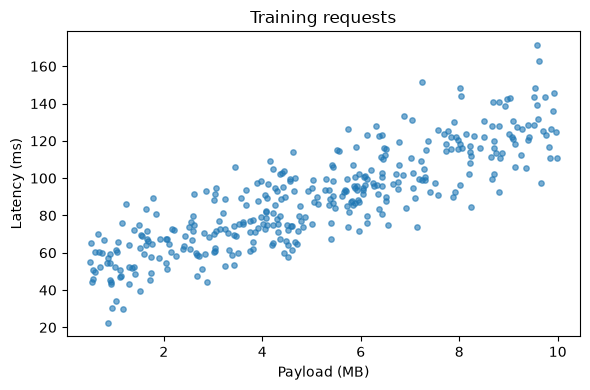

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

rng = np.random.default_rng(17)
n = 600
payload = rng.uniform(0.5, 10, n)
queue = rng.poisson(3, n)
noise = rng.normal(0, 12, n)
latency = 40 + 8 * payload + 3 * queue + noise
payload_copy = payload + rng.normal(0, 0.02, n)

data = pd.DataFrame({
    "payload": payload, "queue": queue,
    "payload_copy": payload_copy, "latency": latency,
})
train_valid, test = train_test_split(data, test_size=0.20, random_state=23)
train, valid = train_test_split(train_valid, test_size=0.25, random_state=23)
assert set(train.index).isdisjoint(valid.index)
assert set(train.index).isdisjoint(test.index)
assert set(valid.index).isdisjoint(test.index)
print("Rows:", {"train": len(train), "validation": len(valid), "test": len(test)})
display(train.head())

plt.figure(figsize=(6, 4))
plt.scatter(train["payload"], train["latency"], s=15, alpha=0.6)
plt.xlabel("Payload (MB)")
plt.ylabel("Latency (ms)")
plt.title("Training requests")
plt.tight_layout()
plt.show()

## 2. Fit the baseline and the payload-only line

The baseline predicts the training mean. Implement
$$w=\frac{\sum(s_i-\bar s)(y_i-\bar y)}{\sum(s_i-\bar s)^2},\qquad b=\bar y-w\bar s.$$
Check it against a reference least-squares fit. A payload slope is measured in ms/MB.

Mean baseline: 88.998 ms
Payload line: latency = 45.849 + 8.524 × payload


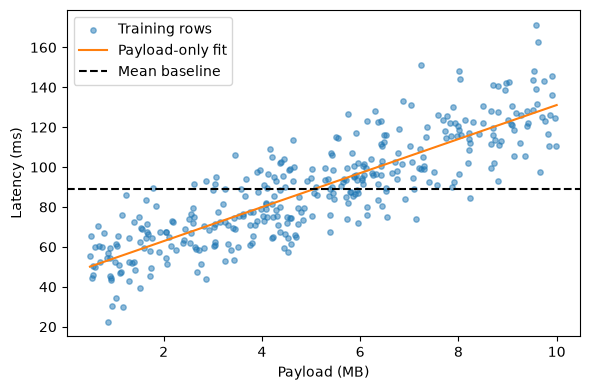

In [2]:
y_train = train["latency"].to_numpy()
s_train = train["payload"].to_numpy()
baseline = y_train.mean()
slope = np.sum((s_train - s_train.mean()) * (y_train - baseline)) / np.sum((s_train - s_train.mean()) ** 2)
intercept = baseline - slope * s_train.mean()
payload_model = LinearRegression().fit(train[["payload"]], y_train)
np.testing.assert_allclose([intercept, slope], [payload_model.intercept_, payload_model.coef_[0]])
print(f"Mean baseline: {baseline:.3f} ms")
print(f"Payload line: latency = {intercept:.3f} + {slope:.3f} × payload")

s_grid = np.linspace(0.5, 10, 100)
plt.figure(figsize=(6, 4))
plt.scatter(s_train, y_train, s=15, alpha=0.5, label="Training rows")
plt.plot(s_grid, intercept + slope * s_grid, color="tab:orange", label="Payload-only fit")
plt.axhline(baseline, color="black", linestyle="--", label="Mean baseline")
plt.xlabel("Payload (MB)")
plt.ylabel("Latency (ms)")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Fit payload and queue using matrices

Construct the design matrix with a leading column of ones. Solve $X\beta\approx y$ using
`np.linalg.lstsq`, not an explicit matrix inverse. Compare with `LinearRegression`.
The payload slope now holds queue length fixed; the queue slope is ms per queued request.

In [3]:
features = ["payload", "queue"]
X_train = train[features].to_numpy()
design = np.column_stack([np.ones(len(train)), X_train])
beta_lstsq = np.linalg.lstsq(design, y_train, rcond=None)[0]
linear_model = LinearRegression().fit(X_train, y_train)
beta_reference = np.r_[linear_model.intercept_, linear_model.coef_]
np.testing.assert_allclose(beta_lstsq, beta_reference, atol=1e-10)
display(pd.DataFrame({
    "generating value": [40, 8, 3],
    "least squares": beta_lstsq,
    "reference fit": beta_reference,
}, index=["intercept (ms)", "payload (ms/MB)", "queue (ms/request)"]))

,generating value,least squares,reference fit
intercept (ms),40,36.235816,36.235816
payload (ms/MB),8,8.411614,8.411614
queue (ms/request),3,3.633601,3.633601


## 4. Implement batch gradient descent

Minimize $J(\beta)=\|X\beta-y\|^2/(2n)$ with gradient $X^T(X\beta-y)/n$.
Use the safe step $1/L$, where $L=\|X\|_2^2/n$.
Stop at gradient norm below $10^{-8}$, with at most 20,000 updates; report convergence.
Run the same algorithm before and after **training-based** standardization.
Convert scaled coefficients back to original units before comparing them.

,least squares,GD raw,"GD scaled, back in original units"
intercept,36.235816,36.235816,36.235816
payload,8.411614,8.411614,8.411614
queue,3.633601,3.633601,3.633601


,updates,converged,max training prediction difference from least squares
raw features,5919,True,6.578854e-08
scaled features,9,True,1.575282e-08


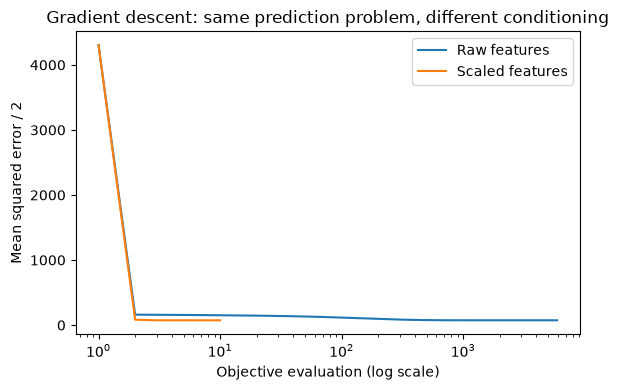

In [4]:
def least_squares_gd(X, y, tolerance=1e-8, max_steps=20000):
    beta = np.zeros(X.shape[1])
    step_size = 1 / (np.linalg.norm(X, ord=2) ** 2 / len(y))
    losses = []
    for step in range(max_steps + 1):
        residual = X @ beta - y
        losses.append(np.mean(residual ** 2) / 2)
        gradient = X.T @ residual / len(y)
        if np.linalg.norm(gradient) < tolerance:
            break
        if step < max_steps:
            beta = beta - step_size * gradient
    converged = np.linalg.norm(gradient) < tolerance
    return beta, np.array(losses), step, converged

beta_raw, loss_raw, steps_raw, ok_raw = least_squares_gd(design, y_train)
scaler = StandardScaler().fit(X_train)
Z_train = scaler.transform(X_train)
design_scaled = np.column_stack([np.ones(len(train)), Z_train])
beta_scaled, loss_scaled, steps_scaled, ok_scaled = least_squares_gd(design_scaled, y_train)

slopes_original = beta_scaled[1:] / scaler.scale_
intercept_original = beta_scaled[0] - slopes_original @ scaler.mean_
beta_scaled_original = np.r_[intercept_original, slopes_original]
assert ok_raw and ok_scaled, "Gradient descent reached its iteration limit."
np.testing.assert_allclose(design @ beta_raw, design @ beta_lstsq, atol=1e-6)
np.testing.assert_allclose(design @ beta_scaled_original, design @ beta_lstsq, atol=1e-6)

display(pd.DataFrame({
    "least squares": beta_lstsq, "GD raw": beta_raw,
    "GD scaled, back in original units": beta_scaled_original,
}, index=["intercept", "payload", "queue"]))
display(pd.DataFrame({
    "updates": [steps_raw, steps_scaled], "converged": [ok_raw, ok_scaled],
    "max training prediction difference from least squares": [
        np.max(np.abs(design @ beta_raw - design @ beta_lstsq)),
        np.max(np.abs(design @ beta_scaled_original - design @ beta_lstsq)),
    ],
}, index=["raw features", "scaled features"]))

plt.figure(figsize=(6, 4))
plt.semilogx(np.arange(len(loss_raw)) + 1, loss_raw, label="Raw features")
plt.semilogx(np.arange(len(loss_scaled)) + 1, loss_scaled, label="Scaled features")
plt.xlabel("Objective evaluation (log scale)")
plt.ylabel("Mean squared error / 2")
plt.title("Gradient descent: same prediction problem, different conditioning")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Select ridge strength on the expanded feature set

Use $(s,q,s')$, standardized within each fit. Here $w=(w_s,w_q,w_{s'})^T$ contains
the three slopes and $\beta=(b,w_s,w_q,w_{s'})^T$ also includes the intercept. Ridge minimizes
$$\frac{1}{2n}\|X\beta-y\|^2+\frac{\lambda}{2}\|w\|^2,$$
without penalizing the intercept. Search $\lambda\in\{10^{-4},10^{-3},10^{-2},10^{-1},1,10\}$
by mean five-fold training CV RMSE. Fit a new scaler in **every fold**.
`Ridge` uses RSS plus `alpha` times the squared slope norm, so `alpha = n_fit * lambda`.
Use the same folds for every candidate; ties go to the smaller lambda by grid order.

In [5]:
expanded_features = ["payload", "queue", "payload_copy"]
X_expanded = train[expanded_features].to_numpy()
lambdas = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1, 10])
folds = list(KFold(n_splits=5, shuffle=True, random_state=23).split(X_expanded))
cv_rows = []
for penalty in lambdas:
    fold_rmse = []
    for fit_rows, score_rows in folds:
        fold_scaler = StandardScaler().fit(X_expanded[fit_rows])
        X_fit = fold_scaler.transform(X_expanded[fit_rows])
        X_score = fold_scaler.transform(X_expanded[score_rows])
        model = Ridge(alpha=len(fit_rows) * penalty)
        model.fit(X_fit, y_train[fit_rows])
        prediction = model.predict(X_score)
        fold_rmse.append(np.sqrt(mean_squared_error(y_train[score_rows], prediction)))
    cv_rows.append({"lambda": penalty, "CV RMSE (ms)": np.mean(fold_rmse),
                    "fold SD (ms)": np.std(fold_rmse, ddof=1)})
cv_results = pd.DataFrame(cv_rows)
best_lambda = float(cv_results.loc[cv_results["CV RMSE (ms)"].idxmin(), "lambda"])
display(cv_results)
print("Frozen ridge lambda:", best_lambda)

expanded_scaler = StandardScaler().fit(X_expanded)
Z_expanded = expanded_scaler.transform(X_expanded)
expanded_ols = LinearRegression().fit(Z_expanded, y_train)
ridge_model = Ridge(alpha=len(train) * best_lambda).fit(Z_expanded, y_train)

,lambda,CV RMSE (ms),fold SD (ms)
0,0.0001,12.183159,1.164548
1,0.0010,12.191812,1.165560
2,0.0100,12.193672,1.166052
3,0.1000,12.247966,1.173147
4,1.0000,14.542320,1.411831
5,10.0000,22.885798,2.160051


Frozen ridge lambda: 0.0001


## 6. Inspect shrinkage and coefficient stability

Plot standardized slope magnitudes over the prespecified ridge grid.
Then take 100 bootstrap resamples of the training rows, refit each scaler and model, and compare
original-unit coefficients and predictions at the fixed request $(s,q,s')=(5,3,5)$.
Keep the selected lambda fixed: this examines fit variability at that setting, not the uncertainty
of the whole selection procedure. Bootstrap variability here is a diagnostic, not a formal confidence interval.

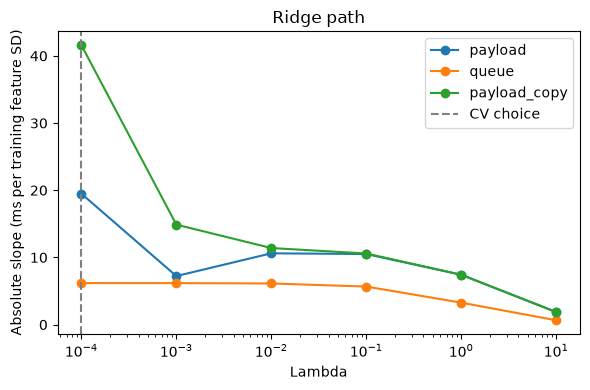

In [6]:
path = []
for penalty in lambdas:
    model = Ridge(alpha=len(train) * penalty).fit(Z_expanded, y_train)
    path.append(model.coef_)
path = np.array(path)
plt.figure(figsize=(6, 4))
for j, feature in enumerate(expanded_features):
    plt.semilogx(lambdas, np.abs(path[:, j]), marker="o", label=feature)
plt.axvline(best_lambda, color="gray", linestyle="--", label="CV choice")
plt.xlabel("Lambda")
plt.ylabel("Absolute slope (ms per training feature SD)")
plt.title("Ridge path")
plt.legend()
plt.tight_layout()
plt.show()

Bootstrap means (coefficients in original units)


model,OLS,Ridge
payload slope,-44.478,-6.753
queue slope,3.655,3.647
copy slope,52.853,15.133
payload + copy slope,8.376,8.379
fixed prediction (ms),89.074,89.106


Bootstrap standard deviations


model,OLS,Ridge
payload slope,33.914,7.668
queue slope,0.441,0.444
copy slope,33.930,7.683
payload + copy slope,0.235,0.234
fixed prediction (ms),0.641,0.630


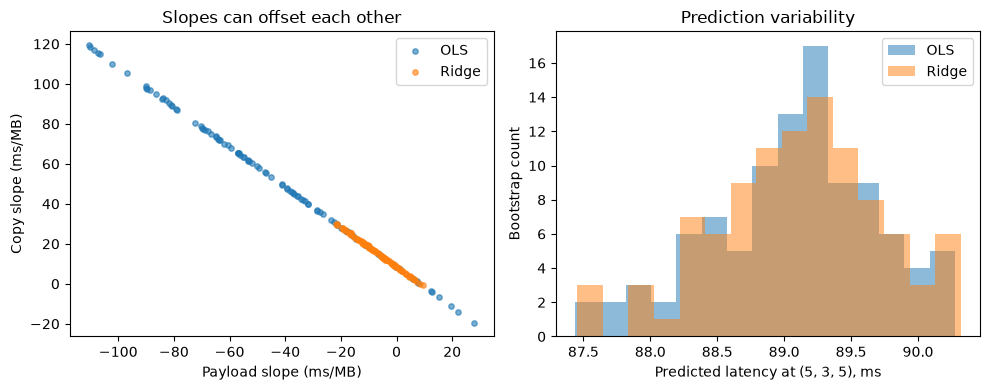

In [7]:
bootstrap_rng = np.random.default_rng(47)
fixed_request = np.array([[5.0, 3.0, 5.0]])
bootstrap_rows = []
for repeat in range(100):
    rows = bootstrap_rng.integers(0, len(train), len(train))
    boot_scaler = StandardScaler().fit(X_expanded[rows])
    X_boot = boot_scaler.transform(X_expanded[rows])
    for name, model in [("OLS", LinearRegression()),
                        ("Ridge", Ridge(alpha=len(rows) * best_lambda))]:
        model.fit(X_boot, y_train[rows])
        raw_slopes = model.coef_ / boot_scaler.scale_
        prediction = model.predict(boot_scaler.transform(fixed_request))[0]
        bootstrap_rows.append({
            "model": name, "payload slope": raw_slopes[0],
            "queue slope": raw_slopes[1], "copy slope": raw_slopes[2],
            "payload + copy slope": raw_slopes[0] + raw_slopes[2],
            "fixed prediction (ms)": prediction,
        })
bootstrap_results = pd.DataFrame(bootstrap_rows)
print("Bootstrap means (coefficients in original units)")
display(bootstrap_results.groupby("model").mean().T.round(3))
print("Bootstrap standard deviations")
display(bootstrap_results.groupby("model").std().T.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for name in ["OLS", "Ridge"]:
    results = bootstrap_results[bootstrap_results["model"] == name]
    axes[0].scatter(results["payload slope"], results["copy slope"], s=15, alpha=0.6, label=name)
    axes[1].hist(results["fixed prediction (ms)"], bins=15, alpha=0.5, label=name)
axes[0].set(xlabel="Payload slope (ms/MB)", ylabel="Copy slope (ms/MB)", title="Slopes can offset each other")
axes[1].set(xlabel="Predicted latency at (5, 3, 5), ms", ylabel="Bootstrap count", title="Prediction variability")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

## 7. Inspect training residuals and audit validation errors

Use the two-feature model for residual plots. Compare the five prespecified models on validation,
without changing the selected lambda. The mean baseline is always the training mean.
Queue and payload are independent in the generator, so omitting queue need not create an obvious
residual trend against payload.

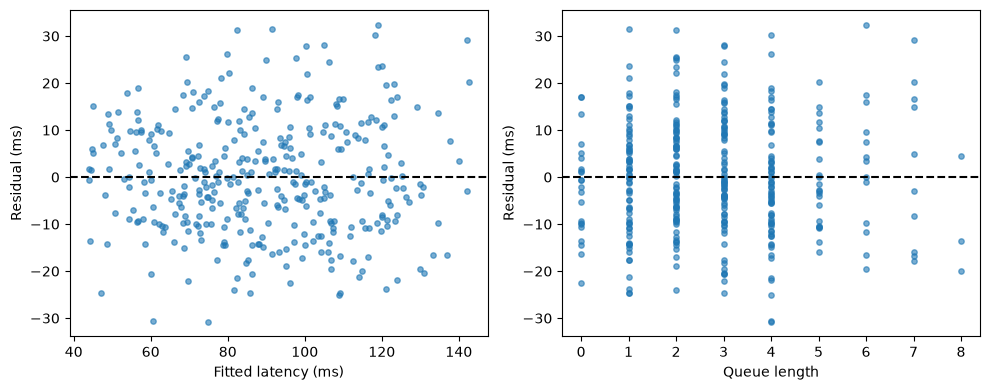

Validation audit — all model choices are already frozen


,MAE (ms),RMSE (ms)
model,,
Training mean,20.788,25.092
Payload only,10.624,13.566
Payload + queue,10.216,12.505
Expanded OLS,10.196,12.594
Expanded ridge (CV),10.193,12.519


In [8]:
fitted = linear_model.predict(X_train)
residuals = y_train - fitted
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(fitted, residuals, s=15, alpha=0.6)
axes[0].set(xlabel="Fitted latency (ms)", ylabel="Residual (ms)")
axes[1].scatter(train["queue"], residuals, s=15, alpha=0.6)
axes[1].set(xlabel="Queue length", ylabel="Residual (ms)")
for ax in axes:
    ax.axhline(0, color="black", linestyle="--")
plt.tight_layout()
plt.show()

def regression_report(frame):
    predictions = {
        "Training mean": np.full(len(frame), baseline),
        "Payload only": payload_model.predict(frame[["payload"]]),
        "Payload + queue": linear_model.predict(frame[features].to_numpy()),
        "Expanded OLS": expanded_ols.predict(expanded_scaler.transform(frame[expanded_features].to_numpy())),
        "Expanded ridge (CV)": ridge_model.predict(expanded_scaler.transform(frame[expanded_features].to_numpy())),
    }
    rows = []
    for name, prediction in predictions.items():
        rows.append({"model": name,
                     "MAE (ms)": mean_absolute_error(frame["latency"], prediction),
                     "RMSE (ms)": np.sqrt(mean_squared_error(frame["latency"], prediction))})
    return pd.DataFrame(rows).set_index("model")

print("Validation audit — all model choices are already frozen")
display(regression_report(valid).round(3))

## 8. Final test evaluation

Evaluate the prespecified models once. This is a comparison of frozen fits, not a second model-selection round.
Report MAE and RMSE in milliseconds. Do not expect the estimated slopes to equal 8 and 3 exactly.

In [9]:
print("Final test results")
test_results = regression_report(test)
display(test_results.round(3))

Final test results


,MAE (ms),RMSE (ms)
model,,
Training mean,21.702,25.810
Payload only,10.427,12.466
Payload + queue,10.299,12.737
Expanded OLS,10.321,12.738
Expanded ridge (CV),10.300,12.729


## Interpret the results

- Check how closely the three numerical solvers agree and how scaling changes the update count.
- Compare the variability of the two payload slopes with their sum and the fixed-request prediction.
  A nearly duplicate feature can make individual slopes unstable without making every prediction unstable.
- Does ridge improve held-out RMSE here? Shrinkage can stabilize coefficients without winning on every test sample.
- The noise SD is 12 ms; even knowing the exact conditional mean would not remove this outcome noise.
- The stability result is about a typical request satisfying the observed relation $s'\approx s$.
  It does not justify extrapolating to requests that violate that relation.

**In the saved run:** scaling reduces gradient descent from 5,919 to 9 updates while
preserving predictions. CV chooses ridge lambda 0.0001. Payload-slope bootstrap SD falls
from about 33.9 to 7.7 ms/MB, while fixed-request prediction SD is about 0.64 ms for OLS
and 0.63 ms for ridge. The payload-only fit happens to have the lowest test RMSE here;
adding the correct queue feature does not guarantee a win on every finite test sample.
These are observations from the stated seeds, not universal rankings.